In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [2]:
train_data = pd.read_csv('../mitsui-commodity-prediction-challenge/train.csv')
test_data = pd.read_csv('../mitsui-commodity-prediction-challenge/test.csv')
pairs = pd.read_csv('../mitsui-commodity-prediction-challenge/target_pairs.csv')
labels = pd.read_csv('../mitsui-commodity-prediction-challenge/train_labels.csv')

In [3]:
train_data


,date_id,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,...,FX_GBPCAD,FX_CADCHF,FX_NZDCAD,FX_NZDCHF,FX_ZAREUR,FX_NOKGBP,FX_NOKCHF,FX_ZARCHF,FX_NOKJPY,FX_ZARGBP
0,0,2264.5,7205.0,2570.0,3349.0,NaN,NaN,NaN,NaN,NaN,...,1.699987,0.776874,0.888115,0.689954,0.066653,0.090582,0.119630,0.078135,13.822740,0.059163
1,1,2228.0,7147.0,2579.0,3327.0,NaN,NaN,NaN,NaN,NaN,...,1.695279,0.778682,0.889488,0.692628,0.067354,0.091297,0.120520,0.079066,13.888146,0.059895
2,2,2250.0,7188.5,2587.0,3362.0,4684.0,4691.0,4684.0,3363.0,3367.0,...,1.692724,0.780186,0.894004,0.697490,0.067394,0.091478,0.120809,0.079287,13.983675,0.060037
3,3,2202.5,7121.0,2540.0,3354.0,4728.0,4737.0,4729.0,3430.0,3426.0,...,1.683111,0.785329,0.889439,0.698502,0.067639,0.091558,0.121021,0.079285,14.035571,0.059983
4,4,2175.0,7125.0,2604.0,3386.0,NaN,NaN,NaN,NaN,NaN,...,1.684816,0.787264,0.891042,0.701485,0.067443,0.091266,0.121055,0.078925,14.013760,0.059503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1912,1912,2450.0,9523.5,1961.5,2676.5,15086.0,15440.0,15085.0,4461.5,4467.0,...,1.864661,0.598318,0.827529,0.495125,0.049224,0.072574,0.080968,0.046175,14.058107,0.041388
1913,1913,2471.5,9519.5,1980.5,2710.5,15165.0,15509.0,15162.0,4495.0,4490.0,...,1.863539,0.594400,0.824390,0.490018,0.049409,0.072828,0.080671,0.046113,14.082236,0.041630
1914,1914,2471.5,9533.5,1974.0,2693.0,15040.0,15477.0,15044.0,4544.5,4555.0,...,1.860067,0.595250,0.822392,0.489529,0.049095,0.073232,0.081083,0.045901,14.126606,0.041457
1915,1915,2456.0,9500.5,1970.0,2697.5,15420.0,15752.0,15420.0,4670.0,4685.0,...,1.859624,0.597780,0.817224,0.488520,0.049205,0.073018,0.081170,0.045987,14.095322,0.041368


In [4]:
train_names = list(train_data.columns)

train_names = [name.replace("open_interest", "open interest")
                    .replace("settlement_price", "settlement price")
                    .replace("US_Stock", "US Stock")
                    .replace("adj_", "adjusted ")
               for name in train_names]

train_names = [re.split("_", name) for name in train_names]



In [5]:
for col in train_names:
    print(col)

['date', 'id']
['LME', 'AH', 'Close']
['LME', 'CA', 'Close']
['LME', 'PB', 'Close']
['LME', 'ZS', 'Close']
['JPX', 'Gold', 'Mini', 'Futures', 'Open']
['JPX', 'Gold', 'Rolling-Spot', 'Futures', 'Open']
['JPX', 'Gold', 'Standard', 'Futures', 'Open']
['JPX', 'Platinum', 'Mini', 'Futures', 'Open']
['JPX', 'Platinum', 'Standard', 'Futures', 'Open']
['JPX', 'RSS3', 'Rubber', 'Futures', 'Open']
['JPX', 'Gold', 'Mini', 'Futures', 'High']
['JPX', 'Gold', 'Rolling-Spot', 'Futures', 'High']
['JPX', 'Gold', 'Standard', 'Futures', 'High']
['JPX', 'Platinum', 'Mini', 'Futures', 'High']
['JPX', 'Platinum', 'Standard', 'Futures', 'High']
['JPX', 'RSS3', 'Rubber', 'Futures', 'High']
['JPX', 'Gold', 'Mini', 'Futures', 'Low']
['JPX', 'Gold', 'Rolling-Spot', 'Futures', 'Low']
['JPX', 'Gold', 'Standard', 'Futures', 'Low']
['JPX', 'Platinum', 'Mini', 'Futures', 'Low']
['JPX', 'Platinum', 'Standard', 'Futures', 'Low']
['JPX', 'RSS3', 'Rubber', 'Futures', 'Low']
['JPX', 'Gold', 'Mini', 'Futures', 'Close']
['J

In [6]:
columnid = list(range(1,len(train_names)+1))
column = list(train_data.columns)
category = [x[0] if len(x) > 0 else "" for x in train_names]

Ticker = [
    "_".join(x[1:len(x)-1]) if len(x) > 2 else "" 
    for x in train_names
]
Type = [x[-1] if len(x) > 0 else "" for x in train_names]

train_info = pd.DataFrame({
    "Column_Id": columnid,
    "Column": column,
    "Category": category,
    "Ticker": Ticker,
    "Type": Type
})

train_info["Ticker"] = train_info.apply(
    lambda row: row["Type"] if row["Ticker"] == "" else row["Ticker"], axis=1

)

print(train_info)

     Column_Id        Column Category  Ticker    Type
0            1       date_id     date      id      id
1            2  LME_AH_Close      LME      AH   Close
2            3  LME_CA_Close      LME      CA   Close
3            4  LME_PB_Close      LME      PB   Close
4            5  LME_ZS_Close      LME      ZS   Close
..         ...           ...      ...     ...     ...
553        554     FX_NOKGBP       FX  NOKGBP  NOKGBP
554        555     FX_NOKCHF       FX  NOKCHF  NOKCHF
555        556     FX_ZARCHF       FX  ZARCHF  ZARCHF
556        557     FX_NOKJPY       FX  NOKJPY  NOKJPY
557        558     FX_ZARGBP       FX  ZARGBP  ZARGBP

[558 rows x 5 columns]


In [7]:
subset = train_info.iloc[1:,:]

summary = (
    subset.groupby("Category")
    .agg(
        column_count = ("Column", "count"),
        ticker_count = ("Ticker", lambda x: x.nunique())
        ).reset_index()
)

print(summary)

   Category  column_count  ticker_count
0        FX            38            38
1       JPX            40             6
2       LME             4             4
3  US Stock           475            95


In [8]:
lme_info = train_info[train_info["Category"] == "LME"]
lme_info

,Column_Id,Column,Category,Ticker,Type
1,2,LME_AH_Close,LME,AH,Close
2,3,LME_CA_Close,LME,CA,Close
3,4,LME_PB_Close,LME,PB,Close
4,5,LME_ZS_Close,LME,ZS,Close


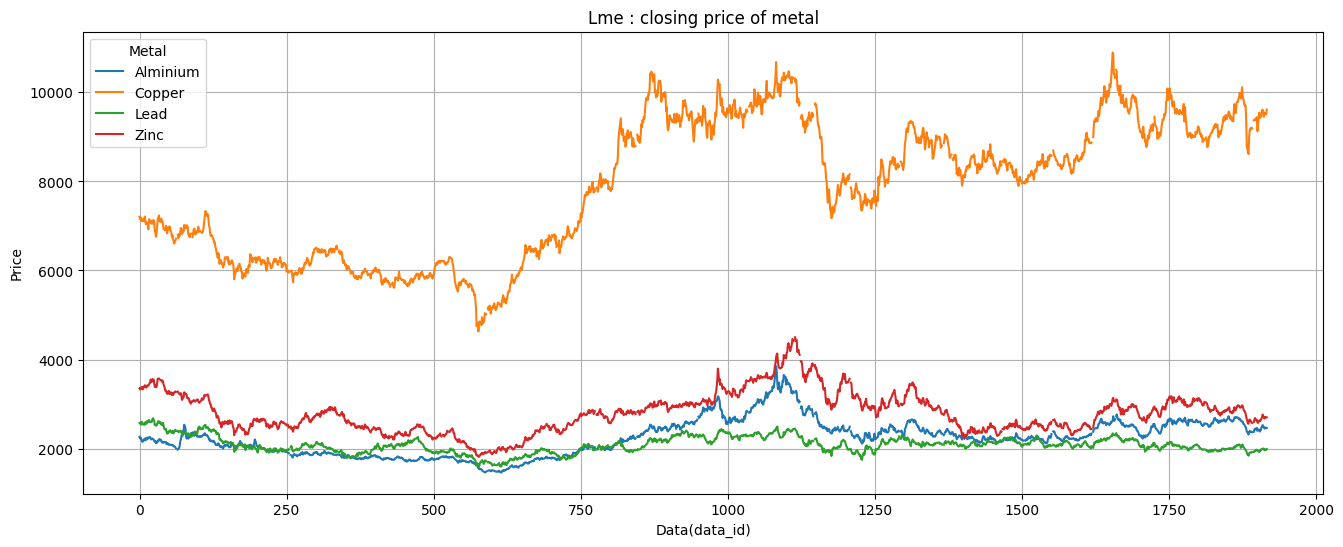

In [9]:
lme_long = train_data.iloc[:,:5]
lme_long.columns = ["date_id", "Alminium", "Copper", "Lead", "Zinc"]
lme_long = lme_long.melt(
    id_vars="date_id",
    var_name = "Metal",
    value_name = "Price"
)

plt.figure(figsize=(16,6))
for metal in lme_long["Metal"].unique():
    metal_data = lme_long[lme_long["Metal"] == metal]
    plt.plot(metal_data["date_id"], metal_data["Price"], label =metal)

plt.xlabel("Data(data_id)")
plt.ylabel("Price")
plt.title("Lme : closing price of metal")
plt.legend(title = "Metal")
plt.grid()
plt.show()

In [10]:
jpx_info = train_info[ (train_info["Category"] == "JPX") & (train_info["Type"] == "Close")]
jpx_info

,Column_Id,Column,Category,Ticker,Type
23,24,JPX_Gold_Mini_Futures_Close,JPX,Gold_Mini_Futures,Close
24,25,JPX_Gold_Rolling-Spot_Futures_Close,JPX,Gold_Rolling-Spot_Futures,Close
25,26,JPX_Gold_Standard_Futures_Close,JPX,Gold_Standard_Futures,Close
26,27,JPX_Platinum_Mini_Futures_Close,JPX,Platinum_Mini_Futures,Close
27,28,JPX_Platinum_Standard_Futures_Close,JPX,Platinum_Standard_Futures,Close
28,29,JPX_RSS3_Rubber_Futures_Close,JPX,RSS3_Rubber_Futures,Close


In [11]:
jpx_iinfo = jpx_info[jpx_info["Type"] == "Close"]

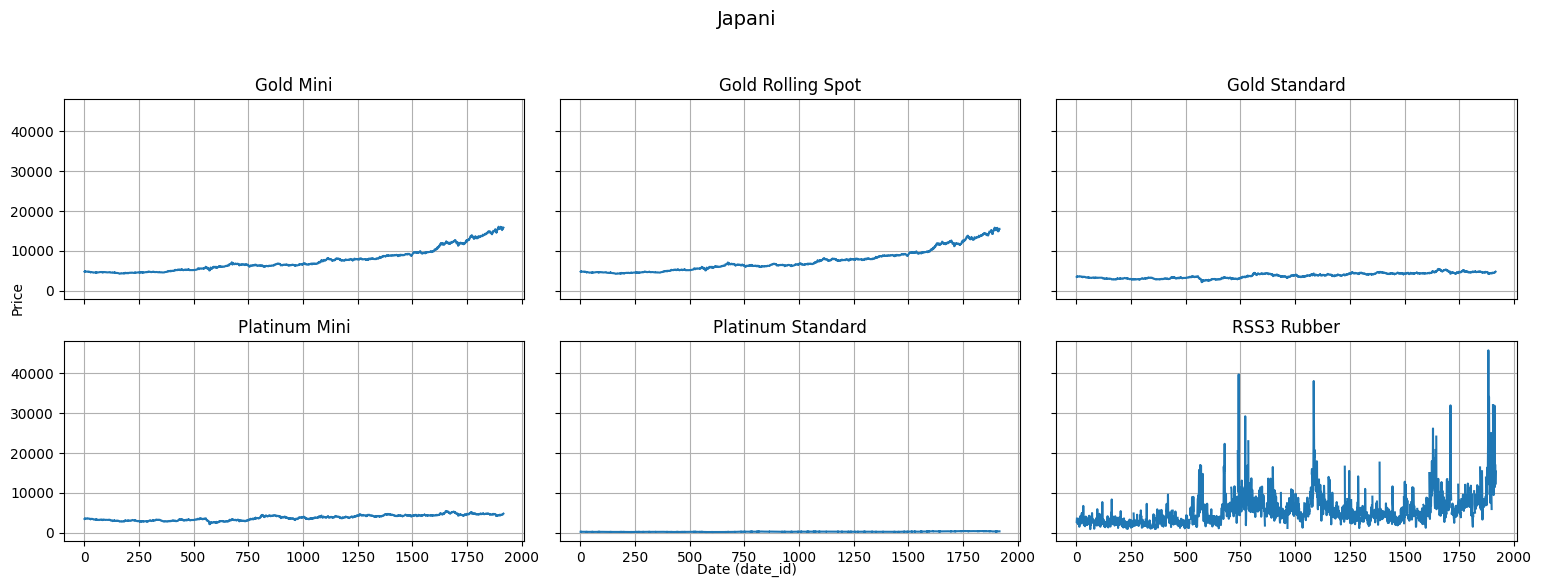

In [12]:
colums =[0] + jpx_iinfo["Column_Id"].tolist()
jpx_long = train_data.iloc[:,colums].copy()

jpx_long.columns = [ "date_id", "Gold Mini", "Gold Rolling Spot", "Gold Standard",
    "Platinum Mini", "Platinum Standard", "RSS3 Rubber"]

jpx_long = jpx_long.melt(
    id_vars= "date_id",
    value_name="Price",
    var_name="Futures"
)

futures_list = jpx_long["Futures"].unique()
ncol = 3 
nrow = (len(futures_list)+ ncol -1) //ncol

fig , axs = plt.subplots(nrow , ncol, figsize= (16,6),sharex = True , sharey = True )
axs = axs.flatten()

for i,future in enumerate(futures_list):
    df = jpx_long[jpx_long["Futures"] == future]
    axs[i].plot(df["date_id"], df["Price"] , color = "tab:blue")
    axs[i].set_title(future)
    axs[i].grid()

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])


fig.suptitle("Japani", fontsize=14)
fig.text(0.5, 0.04, "Date (date_id)", ha='center')
fig.text(0.04, 0.5, "Price", va='center', rotation='vertical')
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

In [13]:
us_info = train_info[(train_info["Category"] == "US Stock") & (train_info["Type"] == "adjusted close")]
us_tkr = us_info["Ticker"].tolist()


In [ ]:
colums =[0] + jpx_iinfo["Column_Id"].tolist()
jpx_long = train_data.iloc[:,colums].copy()

jpx_long.columns = [ "date_id", "Gold Mini", "Gold Rolling Spot", "Gold Standard",
    "Platinum Mini", "Platinum Standard", "RSS3 Rubber"]

jpx_long = jpx_long.melt(
    id_vars= "date_id",
    value_name="Futures",
    var_name="Price"
)

futures_list = jpx_long["Futures"].unique()
ncol = 3 
nrow = (len(futures_list)+ ncol -1) //ncol

fig , axs = plt.subplots(nrow , ncol, figsize= (16,6),sharex = True , sharey = True )
axs = axs.flatten()

for i,future in enumerate(futures_list):
    df = jpx_long[jpx_long["Futures"] == future]
    axs[i].plot(df["date_id"], df["Price"] , color = "tab:blue")
    axs[i].set_title(future)
    axs[i].grid()

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])


fig.suptitle("Japani", fontsize=14)
fig.text(0.5, 0.04, "Date (date_id)", ha='center')
fig.text(0.04, 0.5, "Price", va='center', rotation='vertical')
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

KeyboardInterrupt: 